In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the cleaned CSV data
df = pd.read_csv(
    "C:\\Users\\viktoriya.haiduk\\Desktop\\MIT\\ET6-CDSP-group-03-repo\\1_datasets\\data\\clean_datasets\\infrastructure_damaged_clean.csv"
)


# Display the column names
print(df.columns)

# Show the first 5 rows of the dataset
df.head()

Index(['report_date', 'civic_ext_destroyed', 'edu_ext_destroyed',
       'edu_ext_damaged', 'mosques_ext_destroyed', 'mosques_ext_damaged',
       'churches_ext_destroyed', 'residential_ext_destroyed',
       'residential_destroyed', 'civic_destroyed', 'edu_destroyed',
       'edu_damaged', 'mosques_destroyed', 'mosques_damaged',
       'churches_destroyed'],
      dtype='object')


,report_date,civic_ext_destroyed,edu_ext_destroyed,edu_ext_damaged,mosques_ext_destroyed,mosques_ext_damaged,churches_ext_destroyed,residential_ext_destroyed,residential_destroyed,civic_destroyed,edu_destroyed,edu_damaged,mosques_destroyed,mosques_damaged,churches_destroyed
0,2023-10-07,5,1,15,2,4.0,0,80,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2023-10-08,11,1,30,4,8.0,0,159,159.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023-10-09,16,2,45,6,12.0,0,790,790.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023-10-10,22,2,60,8,17.0,0,1009,1009.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023-10-11,27,3,75,10,21.0,0,2835,2835.0,27.0,3.0,75.0,10.0,0.0,0.0


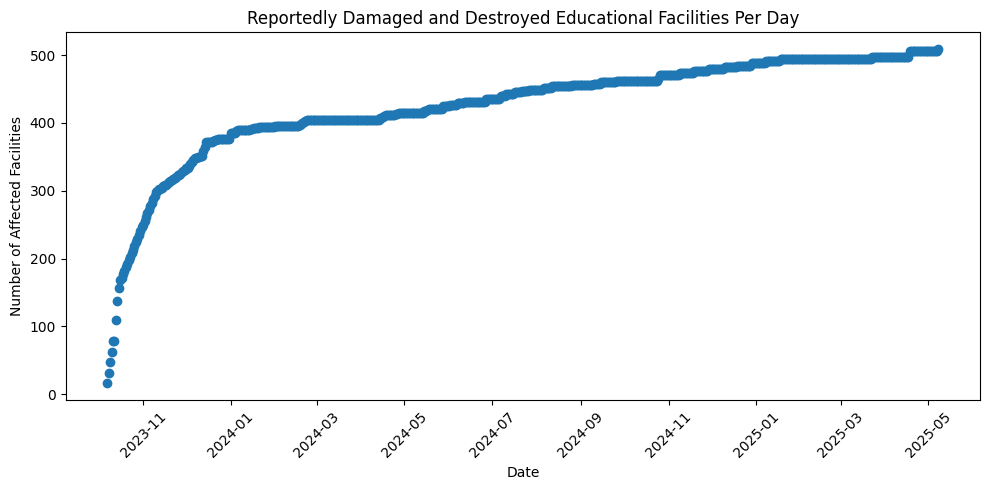

In [10]:
# Convert the 'report_date' column to datetime format
df["report_date"] = pd.to_datetime(df["report_date"])

# Create a new column with the sum of destroyed and damaged education facilities
df["edu_total_ext_impact"] = df["edu_ext_destroyed"] + df["edu_ext_damaged"]

# Group by date and sum the total impact per day
daily_sum = df.groupby(df["report_date"].dt.date)["edu_total_ext_impact"].sum()

# Plot as scatter plot
plt.figure(figsize=(10, 5))
plt.scatter(daily_sum.index, daily_sum.values)

plt.title("Reportedly Damaged and Destroyed Educational Facilities Per Day")
plt.xlabel("Date")
plt.ylabel("Number of Affected Facilities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

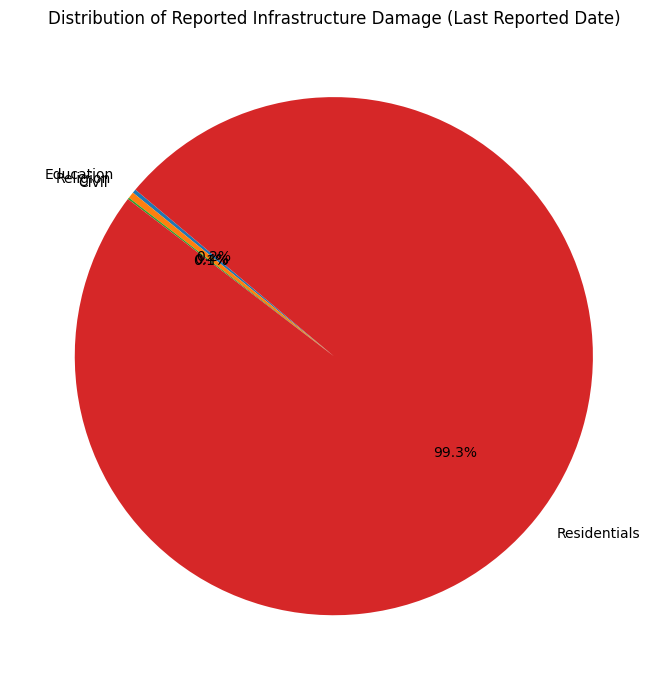

In [12]:
# Select the last row of the DataFrame
last_row = df.iloc[-1]

# Calculate values for each category
education = last_row["edu_ext_destroyed"] + last_row["edu_ext_damaged"]
religion = (
    last_row["mosques_ext_destroyed"]
    + last_row["mosques_ext_damaged"]
    + last_row["churches_ext_destroyed"]
)
civil = last_row["civic_ext_destroyed"]
residentials = last_row["residential_ext_destroyed"]

# Create data and labels
values = [education, religion, civil, residentials]
labels = ["Education", "Religion", "Civil", "Residentials"]

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Reported Infrastructure Damage (Last Reported Date)")
plt.tight_layout()
plt.show()

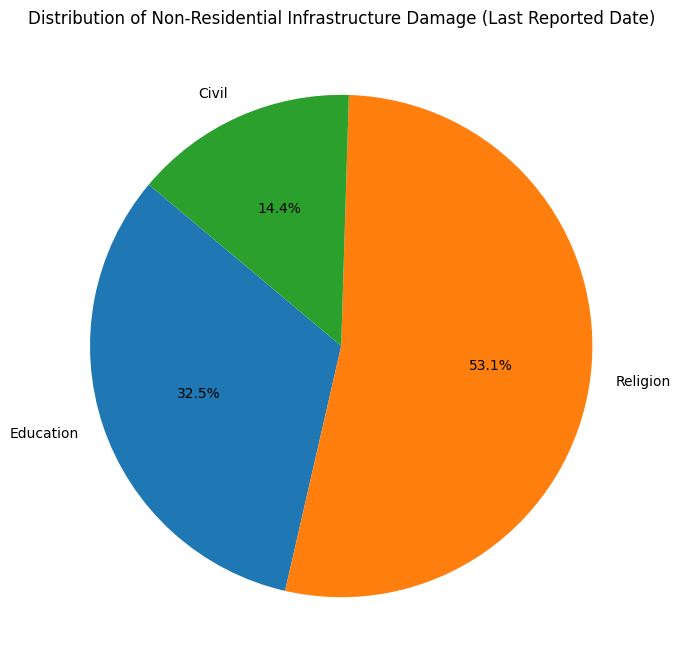

In [13]:
# Select the last row of the DataFrame
last_row = df.iloc[-1]

# Calculate values for each category (excluding residentials)
education = last_row["edu_ext_destroyed"] + last_row["edu_ext_damaged"]
religion = (
    last_row["mosques_ext_destroyed"]
    + last_row["mosques_ext_damaged"]
    + last_row["churches_ext_destroyed"]
)
civil = last_row["civic_ext_destroyed"]

# Create data and labels
values = [education, religion, civil]
labels = ["Education", "Religion", "Civil"]

# Plot pie chart
plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Non-Residential Infrastructure Damage (Last Reported Date)")
plt.tight_layout()
plt.show()

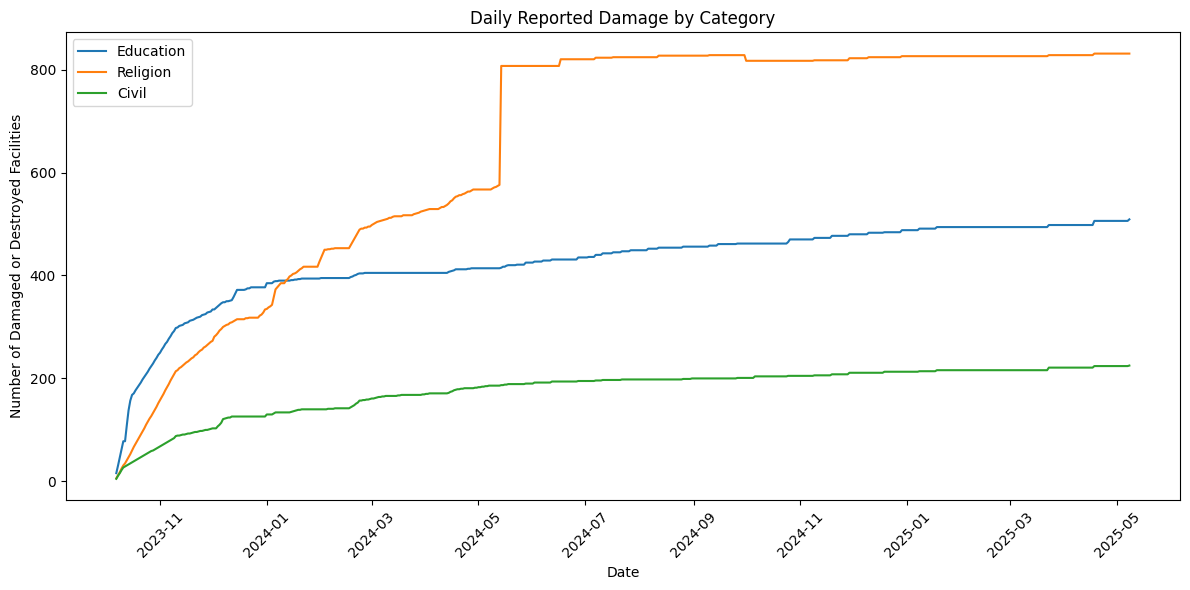

In [15]:
# Ensure 'report_date' is in datetime format
df["report_date"] = pd.to_datetime(df["report_date"])

# Calculate total for each category per row
df["education"] = df["edu_ext_destroyed"] + df["edu_ext_damaged"]
df["religion"] = (
    df["mosques_ext_destroyed"]
    + df["mosques_ext_damaged"]
    + df["churches_ext_destroyed"]
)
df["civil"] = df["civic_ext_destroyed"]

# Group by date and sum each category
daily_summary = df.groupby(df["report_date"].dt.date)[
    ["education", "religion", "civil"]
].sum()

# Plot the line chart
plt.figure(figsize=(12, 6))
plt.plot(daily_summary.index, daily_summary["education"], label="Education")
plt.plot(daily_summary.index, daily_summary["religion"], label="Religion")
plt.plot(daily_summary.index, daily_summary["civil"], label="Civil")

plt.title("Daily Reported Damage by Category")
plt.xlabel("Date")
plt.ylabel("Number of Damaged or Destroyed Facilities")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

Pearson correlation between education and civil damage: 0.97


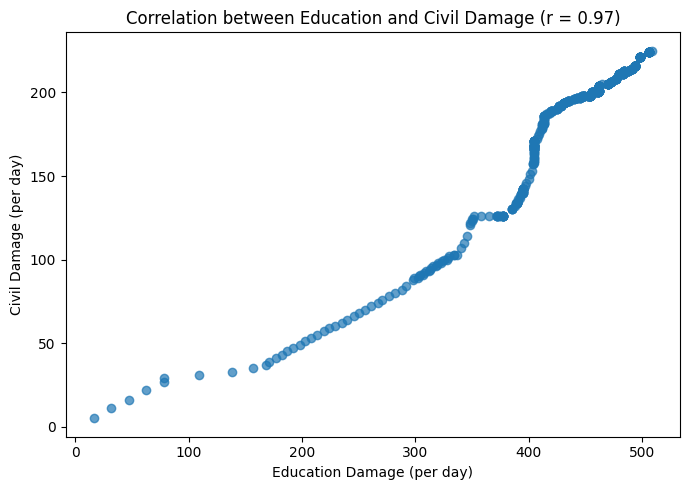

In [16]:
# Ensure 'education' and 'civil' columns are calculated
df["education"] = df["edu_ext_destroyed"] + df["edu_ext_damaged"]
df["civil"] = df["civic_ext_destroyed"]

# Group by date and sum values per day
daily = df.groupby(df["report_date"].dt.date)[["education", "civil"]].sum()

# Calculate Pearson correlation coefficient
correlation = daily["education"].corr(daily["civil"])
print(f"Pearson correlation between education and civil damage: {correlation:.2f}")

# Plot scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(daily["education"], daily["civil"], alpha=0.7)
plt.title(f"Correlation between Education and Civil Damage (r = {correlation:.2f})")
plt.xlabel("Education Damage (per day)")
plt.ylabel("Civil Damage (per day)")
plt.tight_layout()
plt.show()

Pearson correlation between education and religion damage: 0.90


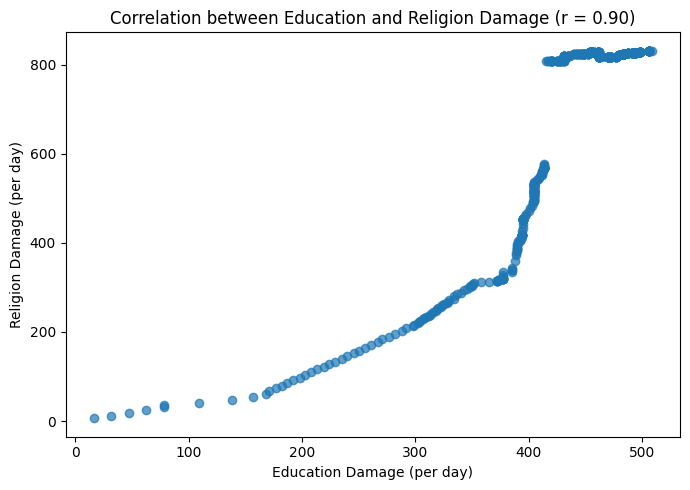

In [17]:
# Ensure 'education' column is calculated
df["education"] = df["edu_ext_destroyed"] + df["edu_ext_damaged"]

# Calculate 'religion' column
df["religion"] = (
    df["mosques_ext_destroyed"]
    + df["mosques_ext_damaged"]
    + df["churches_ext_destroyed"]
)

# Group by date and sum values per day
daily = df.groupby(df["report_date"].dt.date)[["education", "religion"]].sum()

# Calculate Pearson correlation coefficient
correlation = daily["education"].corr(daily["religion"])
print(f"Pearson correlation between education and religion damage: {correlation:.2f}")

# Plot scatter plot
plt.figure(figsize=(7, 5))
plt.scatter(daily["education"], daily["religion"], alpha=0.7)
plt.title(f"Correlation between Education and Religion Damage (r = {correlation:.2f})")
plt.xlabel("Education Damage (per day)")
plt.ylabel("Religion Damage (per day)")
plt.tight_layout()
plt.show()

C:\Users\viktoriya.haiduk\AppData\Local\Temp\ipykernel_9264\3948020747.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_cumulative = daily_cumulative.resample("M").max()


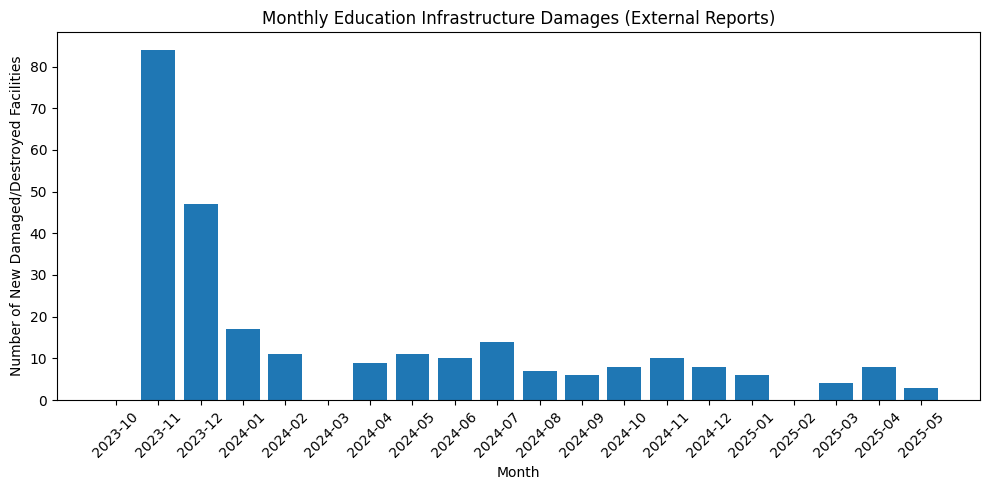

In [12]:
# Ensure 'report_date' is datetime
df["report_date"] = pd.to_datetime(df["report_date"])

# Calculate cumulative total for education
df["education_total"] = df["edu_ext_destroyed"] + df["edu_ext_damaged"]

# Get max cumulative value per day
daily_cumulative = df.groupby(df["report_date"].dt.date)["education_total"].max()

# Convert to datetime index
daily_cumulative.index = pd.to_datetime(daily_cumulative.index)

# Resample to monthly max (cumulative data)
monthly_cumulative = daily_cumulative.resample("M").max()

# Calculate monthly new damages
monthly_new = monthly_cumulative.diff().fillna(0)

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(monthly_new.index.strftime("%Y-%m"), monthly_new.values)

plt.title("Monthly Education Infrastructure Damages (External Reports)")
plt.xlabel("Month")
plt.ylabel("Number of New Damaged/Destroyed Facilities")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [17]:
# Ensure 'report_date' is in datetime format
df["report_date"] = pd.to_datetime(df["report_date"])

# Calculate cumulative total for education
df["education_total"] = df["edu_ext_destroyed"] + df["edu_ext_damaged"]

# Group by day and get maximum cumulative value per day
daily_cumulative = df.groupby(df["report_date"].dt.date)["education_total"].max()

# Compute daily new values (difference between days)
daily_new = daily_cumulative.diff().fillna(0)

# Sort and display top 10 days with highest new education damages
top_10_days = daily_new.sort_values(ascending=False).head(10)

# Display result
print("Top 10 Days with Most Newly Reported Education Infrastructure Damages:")
display(top_10_days)

Top 10 Days with Most Newly Reported Education Infrastructure Damages:


report_date
2023-10-13    31.0
2023-10-14    29.0
2023-10-15    19.0
2023-10-09    16.0
2023-10-11    16.0
2023-10-10    15.0
2023-10-08    15.0
2023-10-16    11.0
2024-01-01     8.0
2025-04-18     8.0
Name: education_total, dtype: float64

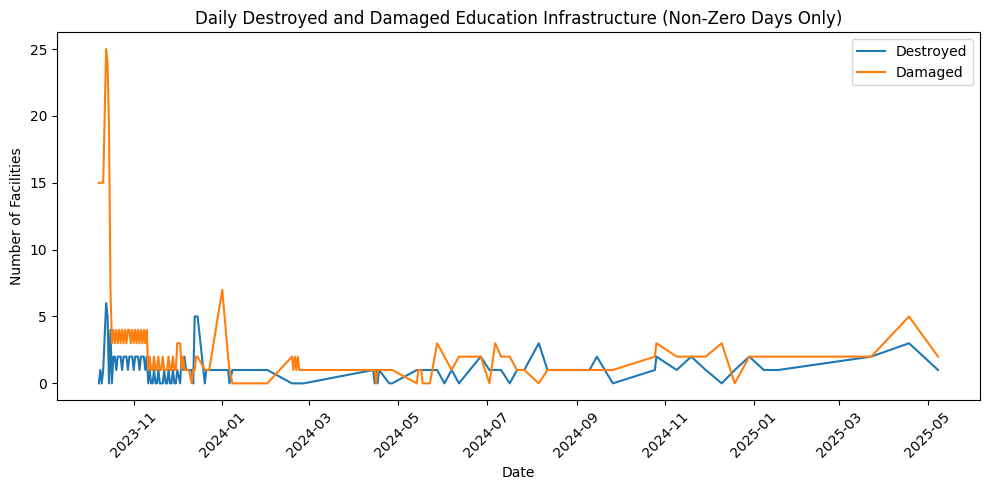

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define relative path to the CSV file
data_path = os.path.join(
    "..", "1_datasets", "data", "clean_datasets", "infrastructure_damaged_clean.csv"
)

# Load the data
df = pd.read_csv(data_path)

# Convert 'report_date' to datetime
df["report_date"] = pd.to_datetime(df["report_date"])

# Get daily maximum values (data is cumulative)
daily_destroyed = df.groupby(df["report_date"].dt.date)["edu_ext_destroyed"].max()
daily_damaged = df.groupby(df["report_date"].dt.date)["edu_ext_damaged"].max()

# Calculate daily new values (difference between days)
new_destroyed = daily_destroyed.diff().fillna(0)
new_damaged = daily_damaged.diff().fillna(0)

# Keep only days with at least some damage or destruction
filtered = pd.DataFrame({"Destroyed": new_destroyed, "Damaged": new_damaged})
filtered = filtered[(filtered["Destroyed"] > 0) | (filtered["Damaged"] > 0)]

# Plot the line chart (without markers)
plt.figure(figsize=(10, 5))
plt.plot(filtered.index, filtered["Destroyed"], label="Destroyed")
plt.plot(filtered.index, filtered["Damaged"], label="Damaged")

plt.title("Daily Destroyed and Damaged Education Infrastructure (Non-Zero Days Only)")
plt.xlabel("Date")
plt.ylabel("Number of Facilities")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\viktoriya.haiduk\AppData\Local\Temp\ipykernel_9264\3714084338.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_destroyed = new_destroyed.resample('M').sum()
C:\Users\viktoriya.haiduk\AppData\Local\Temp\ipykernel_9264\3714084338.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_damaged = new_damaged.resample('M').sum()


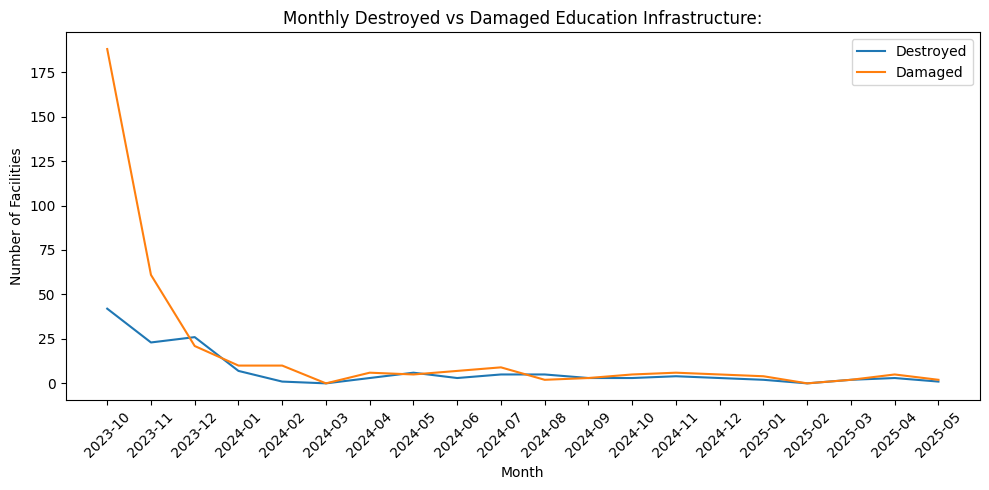

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Define relative path to the CSV file
data_path = os.path.join(
    "..", "1_datasets", "data", "clean_datasets", "infrastructure_damaged_clean.csv"
)

# Load the data
df = pd.read_csv(data_path)

# Convert 'report_date' to datetime
df["report_date"] = pd.to_datetime(df["report_date"])

# Get daily max values (data is cumulative)
daily_destroyed = df.groupby(df["report_date"].dt.date)["edu_ext_destroyed"].max()
daily_damaged = df.groupby(df["report_date"].dt.date)["edu_ext_damaged"].max()

# Convert index to datetime
daily_destroyed.index = pd.to_datetime(daily_destroyed.index)
daily_damaged.index = pd.to_datetime(daily_damaged.index)

# Calculate daily new values
new_destroyed = daily_destroyed.diff().fillna(0)
new_damaged = daily_damaged.diff().fillna(0)

# Resample by month and sum
monthly_destroyed = new_destroyed.resample("M").sum()
monthly_damaged = new_damaged.resample("M").sum()

# Plot monthly data
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_destroyed.index.strftime("%Y-%m"),
    monthly_destroyed.values,
    label="Destroyed",
)
plt.plot(
    monthly_damaged.index.strftime("%Y-%m"), monthly_damaged.values, label="Damaged"
)

plt.title("Monthly Destroyed vs Damaged Education Infrastructure")
plt.xlabel("Month")
plt.ylabel("Number of Facilities")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import os

# Load the data
data_path = os.path.join(
    "..", "1_datasets", "data", "clean_datasets", "infrastructure_damaged_clean.csv"
)
df = pd.read_csv(data_path)
df["report_date"] = pd.to_datetime(df["report_date"])

# Get daily max values (cumulative data)
daily_destroyed = df.groupby(df["report_date"].dt.date)["edu_ext_destroyed"].max()
daily_damaged = df.groupby(df["report_date"].dt.date)["edu_ext_damaged"].max()

# Convert index to datetime
daily_destroyed.index = pd.to_datetime(daily_destroyed.index)
daily_damaged.index = pd.to_datetime(daily_damaged.index)

# Calculate daily new values (difference)
new_destroyed = daily_destroyed.diff().fillna(0)
new_damaged = daily_damaged.diff().fillna(0)

In [6]:
# Calculate the average number of newly destroyed and damaged facilities per active day (non-zero days only)
avg_destroyed = new_destroyed[new_destroyed > 0].mean()
avg_damaged = new_damaged[new_damaged > 0].mean()

# Print results for clarity
print("🟦 Average values per active day:")
print(f"  • Destroyed: {avg_destroyed:.2f}")
print(f"  • Damaged:   {avg_damaged:.2f}")

# Optionally, display as a DataFrame for notebook-friendly output
pd.DataFrame(
    {
        "Metric": ["Destroyed", "Damaged"],
        "Average per active day": [avg_destroyed, avg_damaged],
    }
)

🟦 Average values per active day:
  • Destroyed: 1.61
  • Damaged:   3.13


,Metric,Average per active day
0,Destroyed,1.613636
1,Damaged,3.133929


# 📌 Summary of Key Insights from Visual Analysis

## 📉 Average Impact on Education Facilities per Active Day
- **Destroyed**: 1.61 buildings/day  
- **Damaged**: 3.13 buildings/day

## 🔗 Correlation Analysis
- Strong correlation between education and civil infrastructure damage: **0.97**
- High correlation between education and religious site damage: **0.90**

## 📆 Top Damage Days Identified
The analysis extracted the **Top 10 days** with the most newly reported education infrastructure losses (based on de-cumulated data).

## 📊 Monthly Trends
Monthly aggregation of newly destroyed and damaged education sites showed periods of escalation (details visible in corresponding plots).
